In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [4]:
base_path = r"C:\kdt_0900_lsu\ml\resource\datasets"
file_name = r"pulsar_star.csv"

file_path = os.path.join(base_path, file_name)

In [5]:
df = pd.read_csv(file_path)
df

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,121.156250,48.372971,0.375485,-0.013165,3.168896,18.399367,7.449874,65.159298,0.0
1,76.968750,36.175557,0.712898,3.388719,2.399666,17.570997,9.414652,102.722975,0.0
2,130.585938,53.229534,0.133408,-0.297242,2.743311,22.362553,8.508364,74.031324,0.0
3,156.398438,48.865942,-0.215989,-0.171294,17.471572,NaN,2.958066,7.197842,0.0
4,84.804688,36.117659,0.825013,3.274125,2.790134,20.618009,8.405008,76.291128,0.0
...,...,...,...,...,...,...,...,...,...
12523,124.312500,53.179053,-0.012418,-0.556021,7.186455,29.308266,4.531382,21.725143,0.0
12524,115.617188,46.784600,0.218177,0.226757,6.140468,NaN,5.732201,34.357283,0.0
12525,116.031250,43.213846,0.663456,0.433088,0.785117,11.628149,17.055215,312.204325,0.0
12526,135.664062,49.933749,-0.089940,-0.226726,3.859532,21.501505,7.398395,62.334018,0.0


# 펄서와 우주잡음의 분류(classification) 문제 - KNN이 필요한 모델
- 펄서 별(Pulsar Star) 데이터셋은 지구에 도착한 전파 관측 신호를 바탕으로 치이익- 하는 배경 우주 잡음과 진짜 펄서 별이 보내는 맥박 형태의 전파 신호를 구별하는 이진 분류(Binary Classification) 데이터셋입니다. 자전하며 주기적인 빔을 쏘는 펄서 특유의 물리적 성질 때문에, 일반 잡음과 달리 평균 신호 세기(signal_power)는 낮고 신호의 변동 폭(signal_spread)은 크게 튀는 독특한 데이터 분포를 가집니다.

### 펄서 별(Pulsar Star) 데이터셋 컬럼 명세

| 컬럼명 | 데이터 타입 | 설명 |
| :--- | :--- | :--- |
| **Mean of the integrated profile** | Float | 관측된 전파 신호 통합 프로필의 **평균값** (신호의 전체적인 세기) |
| **Standard deviation of the integrated profile** | Float | 관측된 전파 신호 통합 프로필의 **표준편차** (신호 세기의 변동폭) |
| **Excess kurtosis of the integrated profile** | Float | 관측된 전파 신호 통합 프로필의 **첨도** (신호 분포의 뾰족함 정도) |
| **Skewness of the integrated profile** | Float | 관측된 전파 신호 통합 프로필의 **왜도** (신호 분포의 치우침 정도) |
| **Mean of the DM-SNR curve** | Float | 분산 측정 신호 대 잡음비(DM-SNR) 곡선의 **평균값** |
| **Standard deviation of the DM-SNR curve** | Float | 분산 측정 신호 대 잡음비(DM-SNR) 곡선의 **표준편차** |
| **Excess kurtosis of the DM-SNR curve** | Float | 분산 측정 신호 대 잡음비(DM-SNR) 곡선의 **첨도** |
| **Skewness of the DM-SNR curve** | Float | 분산 측정 신호 대 잡음비(DM-SNR) 곡선의 **왜도** |
| **target_class** | Integer | **클래스 라벨 (0: 우주 잡음 / 1: 진짜 펄서 별)** |

In [6]:
# 데이터 준비

In [7]:
star_df = df[[" Mean of the integrated profile", " Standard deviation of the integrated profile", "target_class"]]
star_df 

,Mean of the integrated profile,Standard deviation of the integrated profile,target_class
0,121.156250,48.372971,0.0
1,76.968750,36.175557,0.0
2,130.585938,53.229534,0.0
3,156.398438,48.865942,0.0
4,84.804688,36.117659,0.0
...,...,...,...
12523,124.312500,53.179053,0.0
12524,115.617188,46.784600,0.0
12525,116.031250,43.213846,0.0
12526,135.664062,49.933749,0.0


In [8]:
star_df.columns = ["signal_mean_power", "signal_spread","target"]

In [9]:
star_df

,signal_mean_power,signal_spread,target
0,121.156250,48.372971,0.0
1,76.968750,36.175557,0.0
2,130.585938,53.229534,0.0
3,156.398438,48.865942,0.0
4,84.804688,36.117659,0.0
...,...,...,...
12523,124.312500,53.179053,0.0
12524,115.617188,46.784600,0.0
12525,116.031250,43.213846,0.0
12526,135.664062,49.933749,0.0


In [10]:
star_df["target"].value_counts()

target
0.0    11375
1.0     1153
Name: count, dtype: int64

## 언더 샘플링 (데이터 불균형 해결)

In [11]:
df_0 = star_df[star_df["target"] == 0]
df_1 = star_df[star_df["target"] == 1]

print(len(df_0), (len(df_1)))

df_0_sampled = df_0.sample(n=len(df_1), random_state=2026)
print(len(df_0_sampled))

11375 1153
1153


In [12]:
print(type(df_1), type(df_0_sampled))

<class 'pandas.core.frame.DataFrame'> <class 'pandas.core.frame.DataFrame'>


In [13]:
pd.concat([df_1, df_0_sampled]). sample(frac =1, random_state=2026).reset_index(drop=True)

,signal_mean_power,signal_spread,target
0,138.820312,49.549602,0.0
1,25.437500,38.225636,1.0
2,34.023438,32.876299,1.0
3,101.093750,47.496289,0.0
4,101.945312,39.955309,0.0
...,...,...,...
2301,155.460938,39.429506,0.0
2302,126.000000,45.366046,0.0
2303,40.062500,30.721722,1.0
2304,40.929688,30.200937,1.0


In [14]:
star_df.head()

,signal_mean_power,signal_spread,target
0,121.156250,48.372971,0.0
1,76.968750,36.175557,0.0
2,130.585938,53.229534,0.0
3,156.398438,48.865942,0.0
4,84.804688,36.117659,0.0


## 사이킷런 KNN 분류 사이클 실습

##  1단계,데이터 전처리

- 데이터 EDA
- 데이터 정보(info) - 결측치 여부확인, 데이터 타입 확인
- 데이터 기술 통계량(descibe) - 4분위수, 이상치
- 결측치, 이상치 처리
- 표준화 또는 정규화

In [15]:
# info -> 에서 확인해야하는건 결측치가 있는지 확인하고 (Non-Null Count), 수치형 데이터인지 분류형 데이터인지 확인 (Dtype)

star_df.info()

# signal_mean_power: 수치
# signal_spread: 수치
# target: 분류

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12528 entries, 0 to 12527
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   signal_mean_power  12528 non-null  float64
 1   signal_spread      12528 non-null  float64
 2   target             12528 non-null  float64
dtypes: float64(3)
memory usage: 293.8 KB


In [16]:
# 진짜 별

star_df.iloc[star_df["signal_mean_power"].idxmin()]

star_df.iloc[star_df["signal_mean_power"].idxmax()]

signal_mean_power    189.734375
signal_spread         59.578268
target                 0.000000
Name: 9254, dtype: float64

In [17]:
star_df.iloc[star_df["signal_spread"].idxmax()]
star_df.iloc[star_df["signal_spread"].idxmin()]

signal_mean_power    27.546875
signal_spread        24.772042
target                1.000000
Name: 7407, dtype: float64

In [18]:
star_df

,signal_mean_power,signal_spread,target
0,121.156250,48.372971,0.0
1,76.968750,36.175557,0.0
2,130.585938,53.229534,0.0
3,156.398438,48.865942,0.0
4,84.804688,36.117659,0.0
...,...,...,...
12523,124.312500,53.179053,0.0
12524,115.617188,46.784600,0.0
12525,116.031250,43.213846,0.0
12526,135.664062,49.933749,0.0


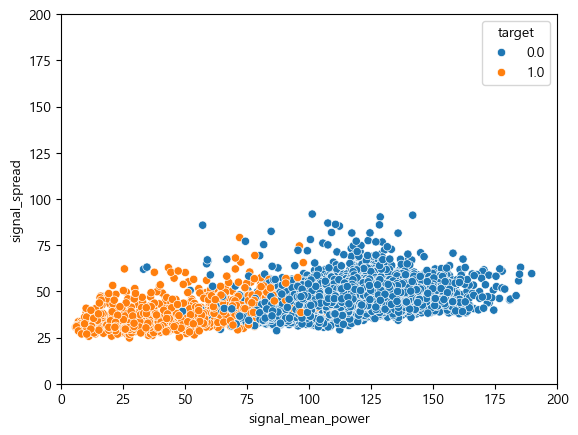

In [19]:
sns. scatterplot(star_df, x="signal_mean_power", y="signal_spread", hue="target")
plt.xlim(0, 200)
plt.ylim(0, 200)
plt.show()

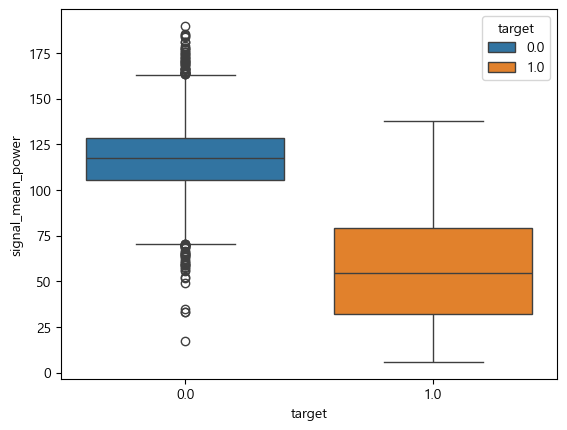

In [20]:
sns.boxplot(star_df, x="target", y="signal_mean_power", hue="target")
plt.show()

# 독립변수와 종속변수 준비

In [21]:
X = star_df.drop("target", axis=1)
X.head()

,signal_mean_power,signal_spread
0,121.156250,48.372971
1,76.968750,36.175557
2,130.585938,53.229534
3,156.398438,48.865942
4,84.804688,36.117659


In [22]:
y = star_df["target"]
y.head()

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: target, dtype: float64

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y,random_state=2026)

In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 하이퍼 파라미터
- 사람(개발자 또는 분석가)가 필요에 따라 직접 섦정하는 파라미터의 값을 의미한다
- 
# 파라미터
- 모델이 학습(fit)을 통해 스스로 찾아내는 값을 의미한다 

In [26]:
kn = KNeighborsClassifier(n_neighbors=5)

# 3단계, 모델학습

In [27]:
kn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [28]:
y_pred = kn.predict(X_test_scaled)
y_pred[::10]

array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
       0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 1., 1.,
       0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
       0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
       0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [29]:
print(f"모델의 정확도 점수: {accuracy_score(y_pred, y_test)}")

모델의 정확도 점수: 0.9704708699122107


In [36]:
# 1~20까지 n_neighbors개수 중 최적의 개수를 찾기

train_scores = []
test_scores = []

for k in range(1, 21):
    kn = KNeighborsClassifier(n_neighbors=k)
    kn.fit(X_train_scaled, y_train)

    train_scores.append(kn.score(X_train_scaled, y_train))
    test_scores.append(kn.score(X_test_scaled, y_test))

In [38]:
print(train_scores)
print(test_scores)

[1.0, 0.9722610257433646, 0.971762123328677, 0.9695669527040511, 0.9700658551187388, 0.969167830772301, 0.9690680502893634, 0.9682698064258631, 0.967870684494113, 0.9681700259429256, 0.9679704649770505, 0.9681700259429256, 0.968070245459988, 0.9679704649770505, 0.967870684494113, 0.9679704649770505, 0.9674715625623628, 0.9674715625623628, 0.9670724406306127, 0.9666733186988625]
[0.9441340782122905, 0.9648842777334398, 0.9652833200319234, 0.9688747007182761, 0.9704708699122107, 0.9704708699122107, 0.9696727853152434, 0.9716679968076616, 0.9708699122106943, 0.9712689545091779, 0.9696727853152434, 0.9708699122106943, 0.970071827613727, 0.9712689545091779, 0.9704708699122107, 0.9712689545091779, 0.9712689545091779, 0.9716679968076616, 0.9720670391061452, 0.9716679968076616]


In [42]:
train_k = train_scores.index(max(train_scores)) + 1
test_k = train_scores.index(max(train_scores)) + 1


print(f"훈련 데이터셋의 최적의 k개수: {train_k}")
print(f"테스트 데이터셋의 최적의 k개수: {test_k}")

훈련 데이터셋의 최적의 k개수: 1
테스트 데이터셋의 최적의 k개수: 1


In [49]:
new_data = pd.DataFrame([[50, 60]], columns=["signal_mean_power","signal_spread"])
new_data_scaled = scaler.transform(new_data)
new_data_scaled

array([[-2.38760042,  1.98410818]])

In [51]:
distanced, index = kn.kneighbors(new_data_scaled)
distanced, index

(array([[0.02447657, 0.18412318, 0.42730251, 0.48562763, 0.48593236,
         0.53545705, 0.7050898 , 0.71819992, 0.75394359, 0.79672947,
         1.01620968, 1.0174029 , 1.02783144, 1.02918281, 1.03229342,
         1.12036356, 1.13294427, 1.15464005, 1.20956998, 1.25058826]]),
 array([[ 799, 1126, 2574, 5802, 5255, 2277, 6086, 8426, 5381, 8771,  716,
         5211, 3634, 8166, 6073, 5174, 1648, 2363, 3404, 2517]],
       dtype=int64))

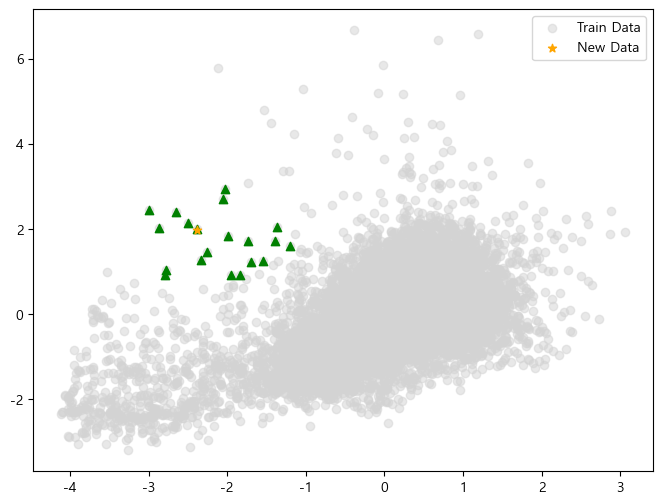

In [70]:
# signal_mean_power, signal_spread
plt.figure(figsize=(8,6))
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c="lightgray", label="Train Data", alpha=0.5)

neighbor_data = X_train_scaled[index[0]]
plt.scatter(neighbor_data[:, 0], neighbor_data[:, 1], marker="^", color="green")
plt.scatter(new_data_scaled[0, 0], new_data_scaled[0, 1], marker="*", color="orange", label="New Data")
plt.legend()

plt.show()

In [71]:
kn.predict(new_data_scaled)

array([1.])

## 4단계 모델 평가 

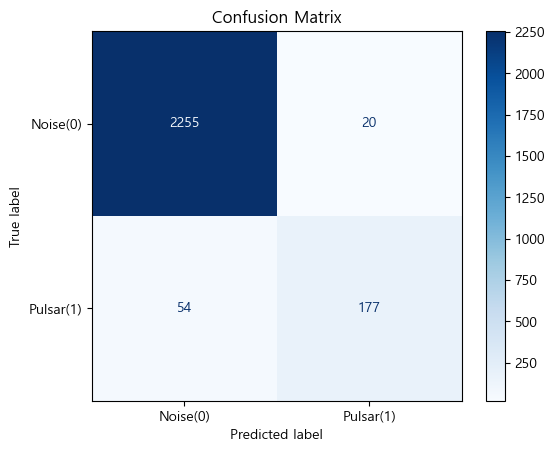

In [64]:
cm = confusion_matrix(y_test,y_pred)
cm

display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Noise(0)", "Pulsar(1)"])
display.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

In [66]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.98      0.99      0.98      2275
         1.0       0.90      0.77      0.83       231

    accuracy                           0.97      2506
   macro avg       0.94      0.88      0.91      2506
weighted avg       0.97      0.97      0.97      2506

